# 04_202 · Transformers planos con cuatro categorías

Reentrena MiniLM multilingüe y E5-small para cuatro daños sobre exactamente el mismo dataset 4:1 y splits usados por `04_205`. `SEGURO` se deriva y `ACOSO_AMENAZA` fusiona acoso personal con amenaza directa.

El arranque es portable: usa directamente el workspace en un kernel local; en Google Colab monta Drive, hace un checkout disperso y reproducible del código desde GitHub, y enlaza sólo los artefactos mínimos persistentes. Prepare o actualice esos artefactos con `scripts_auxiliares/sincronizar_04_20x_google_drive.ps1`.

In [1]:
from pathlib import Path
from importlib.util import find_spec
import json, os, shutil, subprocess, sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

REPO_URL = 'https://github.com/lkoc/Trabajo_PLN-MIA-Grupo4.git'
GIT_COMMIT = 'd7e616e10a0e26e98c8cddb74a3f84ed3198554c'
PROJECT_NAME = 'Trabajo_PLN-MIA-Grupo4'
DRIVE_BUNDLE_NAME = 'PLN_colab_04_artifacts'
NEEDS_PEFT = False

def _bootstrap_04_20x():
    try:
        from google.colab import drive
        in_colab = True
    except ImportError:
        drive, in_colab = None, False
    if not in_colab:
        start = Path.cwd().resolve()
        root = next((p for p in (start, *start.parents) if (p / 'scripts_auxiliares').is_dir()), None)
        if root is None:
            raise FileNotFoundError('No se encontró la raíz local del proyecto.')
        return root, in_colab, root, 'working-tree-local'
    drive.mount('/content/drive', force_remount=False)
    artifact_root = Path('/content/drive/MyDrive') / DRIVE_BUNDLE_NAME
    manifest_path = artifact_root / 'MANIFIESTO_ARTEFACTOS_04_20X.json'
    if not manifest_path.is_file():
        raise FileNotFoundError('Falta el bundle de Drive. Ejecute localmente scripts_auxiliares/sincronizar_04_20x_google_drive.ps1.')
    manifest = json.loads(manifest_path.read_text(encoding='utf-8-sig'))
    missing = [r['path'] for r in manifest['files'] if not (artifact_root / r['path']).is_file()]
    if missing:
        raise FileNotFoundError('Bundle incompleto en Drive:\n' + '\n'.join(missing))
    root = Path('/content') / PROJECT_NAME
    if not (root / '.git').is_dir():
        if root.exists():
            raise RuntimeError(f'Ruta no administrada ya existente: {root}')
        subprocess.run(['git', 'clone', '--filter=blob:none', '--no-checkout', REPO_URL, str(root)], check=True)
    current = subprocess.check_output(['git', '-C', str(root), 'rev-parse', 'HEAD'], text=True).strip()
    if current != GIT_COMMIT:
        subprocess.run(['git', '-C', str(root), 'fetch', '--depth', '1', 'origin', GIT_COMMIT], check=True)
    subprocess.run(['git', '-C', str(root), 'sparse-checkout', 'set', 'scripts_auxiliares'], check=True)
    subprocess.run(['git', '-C', str(root), 'checkout', '--detach', GIT_COMMIT], check=True)
    for name in ('datos', 'modelos', 'resultados'):
        local, target = root / name, artifact_root / name
        target.mkdir(parents=True, exist_ok=True)
        if local.is_symlink() and local.resolve() == target.resolve():
            continue
        if local.is_symlink(): local.unlink()
        elif local.exists(): raise RuntimeError(f'Ruta de artefactos no administrada: {local}')
        local.symlink_to(target, target_is_directory=True)
    return root, in_colab, artifact_root, GIT_COMMIT

ROOT, IN_COLAB, ARTIFACT_ROOT, CODE_VERSION = _bootstrap_04_20x()
if IN_COLAB:
    packages = {'transformers': 'transformers>=4.51,<6', 'sklearn': 'scikit-learn>=1.4'}
    if NEEDS_PEFT: packages['peft'] = 'peft>=0.15,<1'
    missing_packages = [package for module, package in packages.items() if find_spec(module) is None]
    if missing_packages: subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *missing_packages], check=True)
os.environ['PLN_PROJECT_ROOT'] = str(ROOT)
os.environ['PLN_ARTIFACT_ROOT'] = str(ARTIFACT_ROOT)
os.chdir(ROOT)
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from scripts_auxiliares import entrenar_transformers_planos_4 as t4
from scripts_auxiliares import experimentos_jerarquicos_4 as h4
print('Entorno:', 'Google Colab híbrido' if IN_COLAB else 'local')
print('Código:', ROOT, CODE_VERSION)
print('Artefactos persistentes:', ARTIFACT_ROOT)
print('Dispositivo:', h4.device())
print('Modelos:', t4.MODEL_KEYS)
print('Objetivos:', t4.TARGET_LABELS)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Entorno: Google Colab híbrido
Código: /content/Trabajo_PLN-MIA-Grupo4 5415bc722c65a5930ef5de05e4ae932a287998c1
Artefactos persistentes: /content/drive/MyDrive/PLN_colab_04_artifacts
Dispositivo: cuda
Modelos: ('paraphrase_minilm', 'e5_small')
Objetivos: ['RACISMO_DISCRIMINACION', 'ACOSO_GENERO_IDENTIDAD', 'ACOSO_AMENAZA', 'CONTENIDO_SEXUAL']


## 1. Contrato común de datos

El hash del dataset, manifiesto y checkpoints fuente se integra en un fingerprint. Si cualquiera cambia, un resultado anterior no se reutiliza silenciosamente.

In [2]:
context = t4.load_context()
summary = t4.dataset_summary(context)
display(summary)
print('Dataset SHA-256:', context['dataset_sha256'])
print('Fingerprint:', context['training_fingerprint_sha256'])

,split,rows,videos,safe,damage,RACISMO_DISCRIMINACION,ACOSO_GENERO_IDENTIDAD,ACOSO_AMENAZA,CONTENIDO_SEXUAL
0,train,24701,2086,19757,4944,1319,1394,2077,1613
1,validation,5324,448,4246,1078,281,304,488,334
2,test,5290,448,4249,1041,256,263,463,335


Dataset SHA-256: df2ac01183271e44b6dcfb9cb4850bd6b1ef1cd11d9fc51c881be944670ef20f
Fingerprint: 2c2fe7ce9dfcfd19d38a8e4f99c4f4d873febc7596a92a2dedebc4fee1861f26


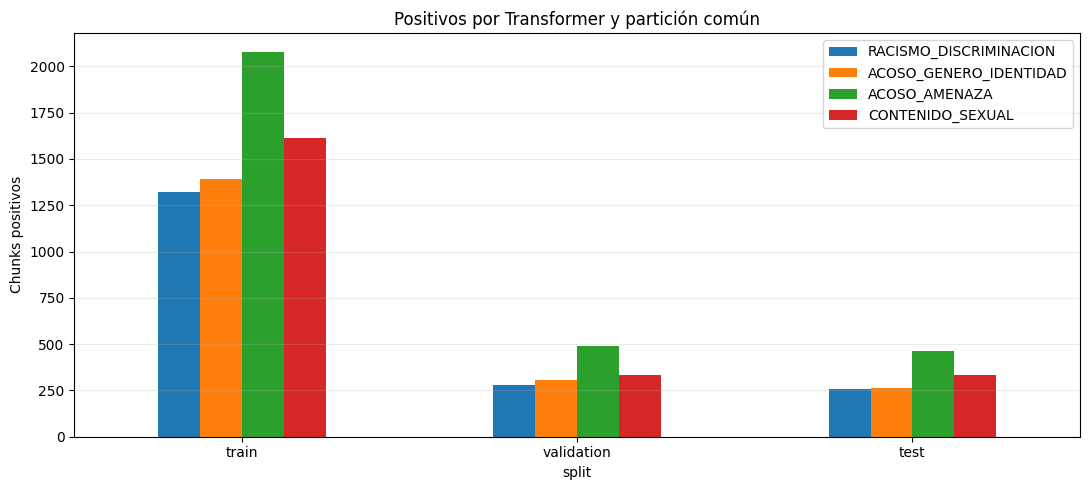

In [4]:
ax = summary.set_index('split')[t4.TARGET_LABELS].plot.bar(figsize=(11, 5))
ax.set_title('Positivos por Transformer y partición común')
ax.set_ylabel('Chunks positivos')
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Transferencia y entrenamiento

Cada modelo parte de su checkpoint completo de `04_2`. Se copia el encoder adaptado al dominio; las filas de racismo, género y sexual se conservan y `ACOSO_AMENAZA` se inicializa con el promedio de las filas anteriores de acoso y amenaza. La cabeza y el encoder vuelven a optimizarse. Los umbrales históricos se descartan.

Se permiten hasta tres épocas con parada temprana según PR-AUC macro de validation. Se guardan `best_checkpoint`, `last_checkpoint`, historial por época, scores y reportes. Test no interviene en la elección de modelo o época.

In [5]:
FORCE = False
result = t4.run_all(force=FORCE)
display(result['selection'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

...

e5_small · validation época 2:   0%|          | 0/167 [00:00<?, ?lote/s]

e5_small época 2: PR-AUC=0.4890; F1=0.5251


e5_small · validation final:   0%|          | 0/167 [00:00<?, ?lote/s]

e5_small · test final:   0%|          | 0/166 [00:00<?, ?lote/s]

{'partition': 'validation',
 'metric': 'damage_pr_auc_macro',
 'winner_key': 'e5_small',
 'winner_label': 'Multilingual E5-small (linaje MiniLM)',
 'test_used_for_selection': False}

### paraphrase_minilm

,epoch,training_loss,validation_damage_pr_auc_macro,validation_damage_f1_macro,validation_any_damage_recall,thresholds
0,1,0.416011,0.481929,0.507591,0.627087,"[0.37499999999999994, 0.44999999999999996, 0.6..."
1,2,0.336994,0.479395,0.513722,0.618738,"[0.32499999999999996, 0.125, 0.324999999999999..."


### e5_small

,epoch,training_loss,validation_damage_pr_auc_macro,validation_damage_f1_macro,validation_any_damage_recall,thresholds
0,1,0.438061,0.504120,0.523874,0.74026,"[0.44999999999999996, 0.49999999999999994, 0.4..."
1,2,0.383253,0.488956,0.525103,0.64564,"[0.3, 0.65, 0.37499999999999994, 0.9]"


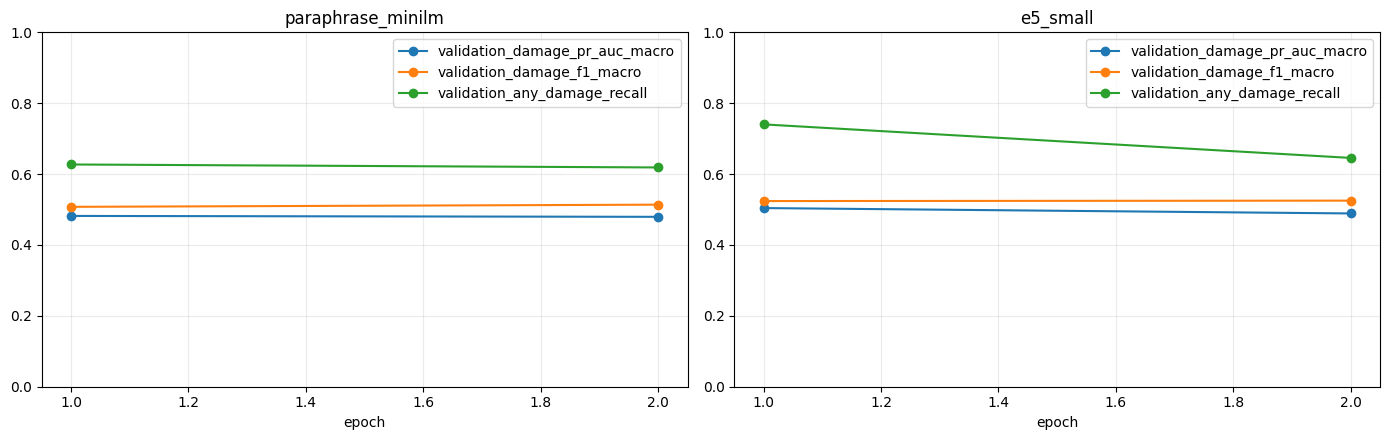

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, key in zip(axes, t4.MODEL_KEYS):
    history = pd.DataFrame(result['models'][key]['history'])
    display(Markdown(f'### {key}'))
    display(history)
    history.plot(x='epoch', y=['validation_damage_pr_auc_macro', 'validation_damage_f1_macro', 'validation_any_damage_recall'], marker='o', ax=ax)
    ax.set_title(key)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 3. Comparación final plana

,model_key,modelo,split,damage_pr_auc_macro,damage_f1_macro,damage_recall_micro,any_damage_precision,any_damage_recall,missed_damage_as_safe
0,paraphrase_minilm,Paraphrase Multilingual MiniLM-L12,validation,0.481929,0.507591,0.502488,0.604651,0.627087,402
1,paraphrase_minilm,Paraphrase Multilingual MiniLM-L12,test,0.482037,0.497847,0.517084,0.594571,0.652257,362
2,e5_small,Multilingual E5-small (linaje MiniLM),validation,0.504120,0.523874,0.571429,0.559607,0.740260,280
3,e5_small,Multilingual E5-small (linaje MiniLM),test,0.475221,0.517196,0.599089,0.532827,0.740634,270


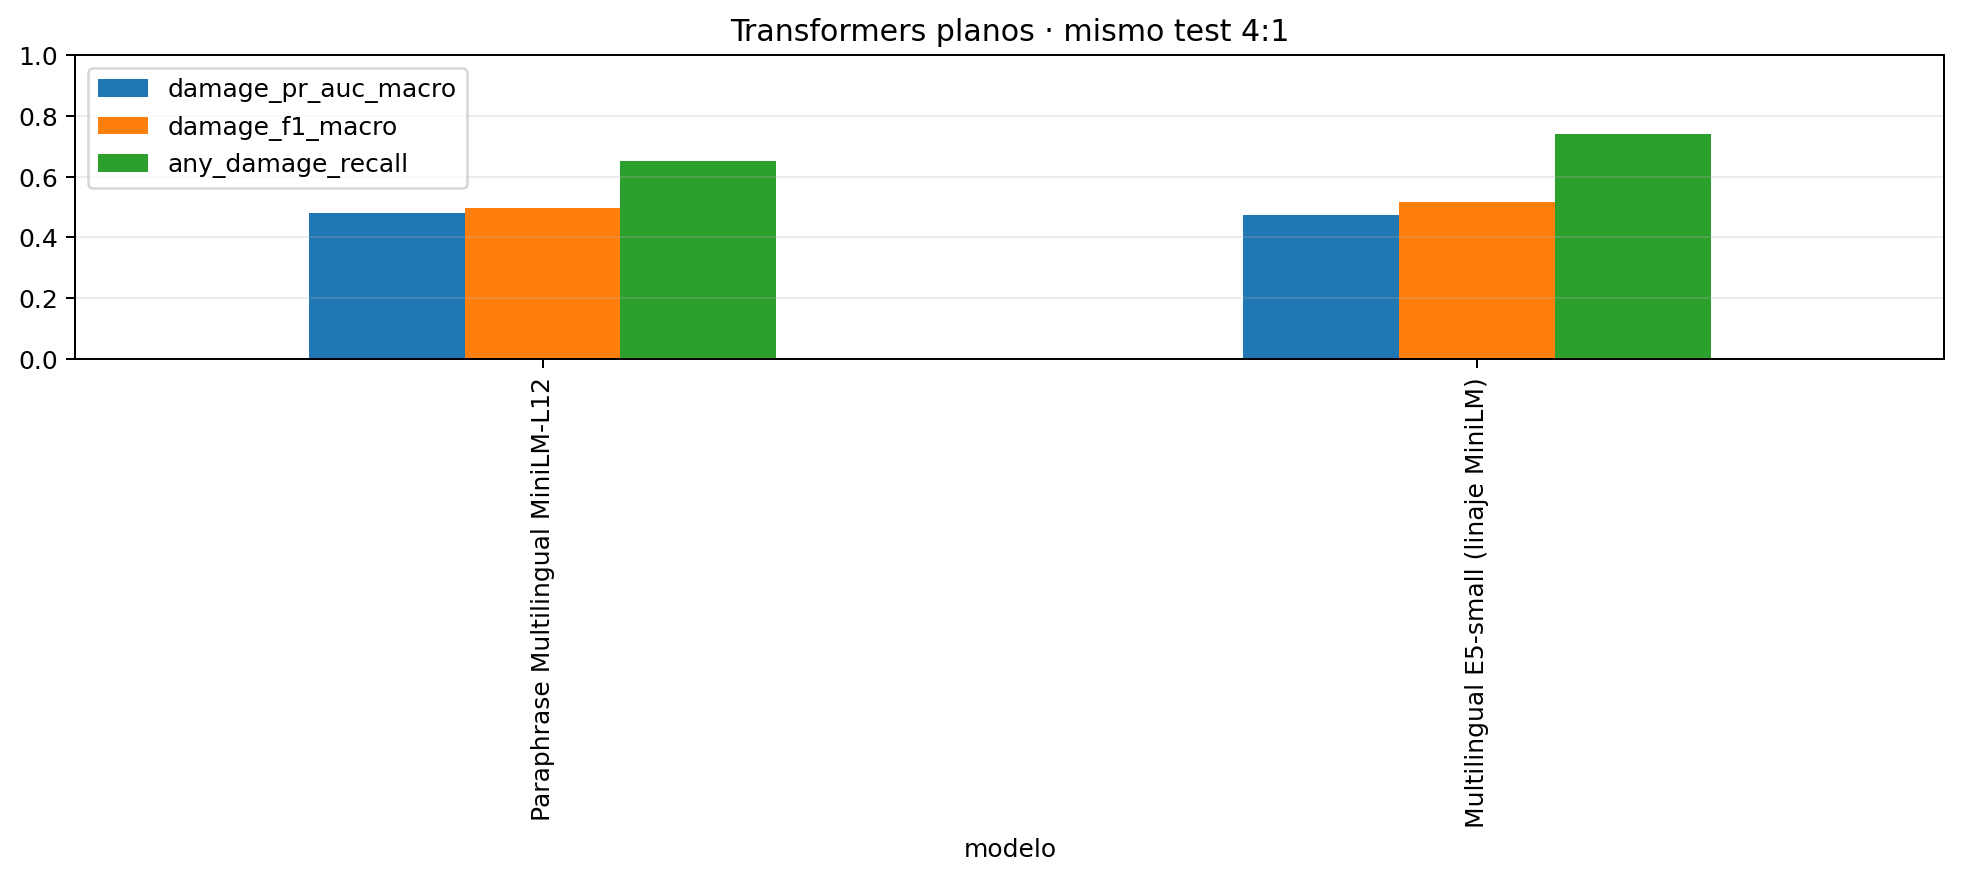

**Resultado:** `resultados/metricas/transformer_plano_4/resultado.json`  
**Informe:** `resultados/INFORME_TRANSFORMERS_PLANOS_4.md`  
**Modelos:** `modelos/transformer_plano_4`

In [7]:
comparison = pd.read_csv(t4.METRICS_DIR / 'comparacion.csv')
display(comparison)
display(Image(filename=str(t4.FIGURES_DIR / 'comparacion_test.png')))
display(Markdown(
    f'**Resultado:** `{t4.RESULT_PATH.relative_to(ROOT)}`  \n'
    f'**Informe:** `{t4.REPORT_PATH.relative_to(ROOT)}`  \n'
    f'**Modelos:** `{t4.MODEL_DIR.relative_to(ROOT)}`'
))

## Referencias (APA 7)

Cawley, G. C., & Talbot, N. L. C. (2010). On over-fitting in model selection and subsequent selection bias in performance evaluation. *Journal of Machine Learning Research, 11*, 2079–2107. https://www.jmlr.org/papers/v11/cawley10a.html

Saito, T., & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. *PLOS ONE, 10*(3), e0118432. https://doi.org/10.1371/journal.pone.0118432